In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 데이터 로드
data = pd.read_csv('C:/Users/minky/Desktop/Apart Deal.csv', encoding='cp949')

# 결측치 및 타입 처리
data = data.dropna(subset=['전용면적', '거래금액'])
data['전용면적'] = pd.to_numeric(data['전용면적'], errors='coerce')
data['거래금액'] = pd.to_numeric(data['거래금액'], errors='coerce')

# 이상치 제거 (IQR 방식)
for col in ['전용면적', '거래금액']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

# 날짜 파생 변수
data['거래일'] = pd.to_datetime(data['거래일'], errors='coerce')
data['거래년'] = data['거래일'].dt.year
data['거래월'] = data['거래일'].dt.month

# 지역 코드 라벨 인코딩
data['지역대분류'] = data['지역코드'].astype(str).str[:2]
le = LabelEncoder()
data['지역대분류_encoded'] = le.fit_transform(data['지역대분류'])

# K-Fold Target Encoding 함수
def kfold_target_encoding(data, target_col, cat_col, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    encoded_feature = pd.Series(index=data.index, dtype='float64')
    for train_idx, valid_idx in kf.split(data):
        train_data, valid_data = data.iloc[train_idx], data.iloc[valid_idx]
        means = train_data.groupby(cat_col)[target_col].mean()
        encoded_feature.iloc[valid_idx] = valid_data[cat_col].map(means)
    return encoded_feature

# 적용: 아파트 이름에 대해 K-Fold Target Encoding
data['아파트_mean_price'] = kfold_target_encoding(data, '거래금액', '아파트', n_splits=10)
data = data.drop(columns=['법정동', '지번', '아파트'])

# 특성 변수 정의 및 스케일링
features = ['전용면적', '층', '건축년도', '거래년', '거래월', '지역대분류_encoded', '아파트_mean_price']
X = data[features]
y = data['거래금액']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 모델 정의 및 평가
model = lgb.LGBMRegressor(random_state=42)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores, rmse_scores, mape_scores = [], [], []
for train_idx, test_idx in kf.split(X_scaled):
    model.fit(X_scaled[train_idx], y.iloc[train_idx])
    preds = model.predict(X_scaled[test_idx])
    mae_scores.append(mean_absolute_error(y.iloc[test_idx], preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y.iloc[test_idx], preds)))
    mape_scores.append(mean_absolute_percentage_error(y.iloc[test_idx], preds))

# 최종 출력
print(f"10-Fold MAE 평균: {np.mean(mae_scores):.2f}")
print(f"10-Fold RMSE 평균: {np.mean(rmse_scores):.2f}")
print(f"10-Fold MAPE 평균: {np.mean(mape_scores)*100:.2f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 832601, number of used features: 7
[LightGBM] [Info] Start training from score 26143.593508


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 832601, number of used features: 7
[LightGBM] [Info] Start training from score 26138.710902


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 832601, number of used features: 7
[LightGBM] [Info] Start training from score 26144.079332


...

c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 658
[LightGBM] [Info] Number of data points in the train set: 832602, number of used features: 7
[LightGBM] [Info] Start training from score 26146.094793


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 832602, number of used features: 7
[LightGBM] [Info] Start training from score 26140.834921
10-Fold MAE 평균: 2969.82
10-Fold RMSE 평균: 4484.28
10-Fold MAPE 평균: 14.25%


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [5]:
print(f"MAE 최소값: {np.min(mae_scores):.2f}, 최대값: {np.max(mae_scores):.2f}")
print(f"RMSE 최소값: {np.min(rmse_scores):.2f}, 최대값: {np.max(rmse_scores):.2f}")
print(f"MAPE 최소값: {np.min(mape_scores)*100:.2f}%, 최대값: {np.max(mape_scores)*100:.2f}%")

MAE 최소값: 2959.25, 최대값: 2996.14
RMSE 최소값: 4452.14, 최대값: 4525.28
MAPE 최소값: 14.15%, 최대값: 14.41%


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


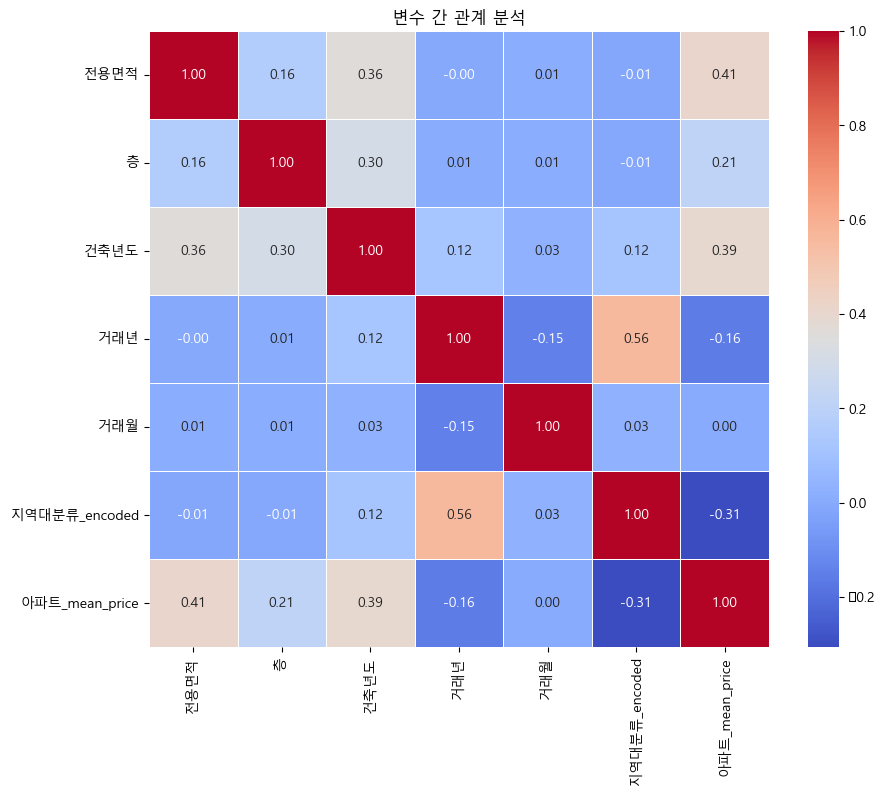

In [6]:
#변수 간 관계 분석
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
plt.rcParams['font.family'] = 'Malgun Gothic'

# 상관 행렬 계산
corr = X.corr()

# 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("변수 간 관계 분석")
plt.show()


In [7]:
# LightGBM 모델 재정의 및 전체 데이터로 훈련 (feature importance 시각화를 위한 훈련)
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_scaled, y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 925113, number of used features: 7
[LightGBM] [Info] Start training from score 26142.073726


LGBMRegressor(random_state=42)

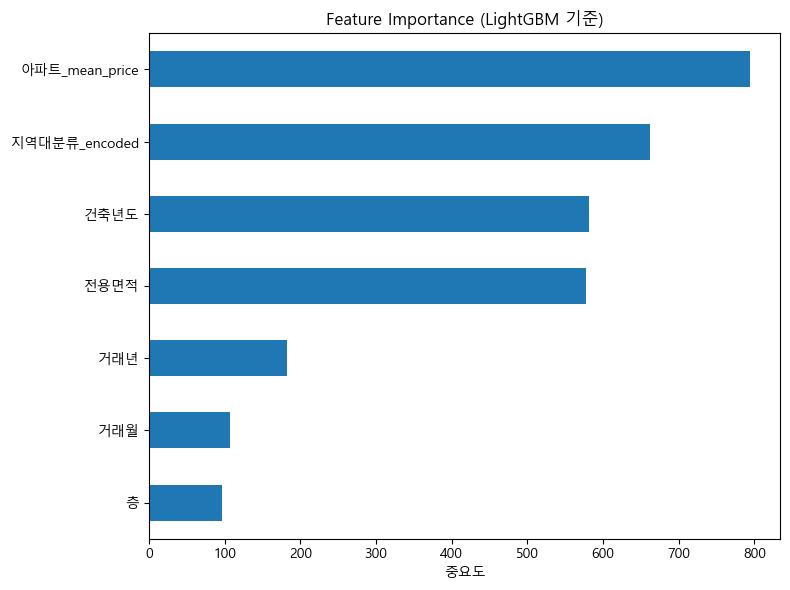

In [8]:
importances = model.feature_importances_
feature_names = ['전용면적', '층', '건축년도', '거래년', '거래월', '지역대분류_encoded', '아파트_mean_price']

# 시리즈로 만들어 정렬
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# 시각화
plt.figure(figsize=(8, 6))
importance_df.plot(kind='barh')
plt.title("Feature Importance (LightGBM 기준)")
plt.xlabel("중요도")
plt.tight_layout()
plt.show()


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserW

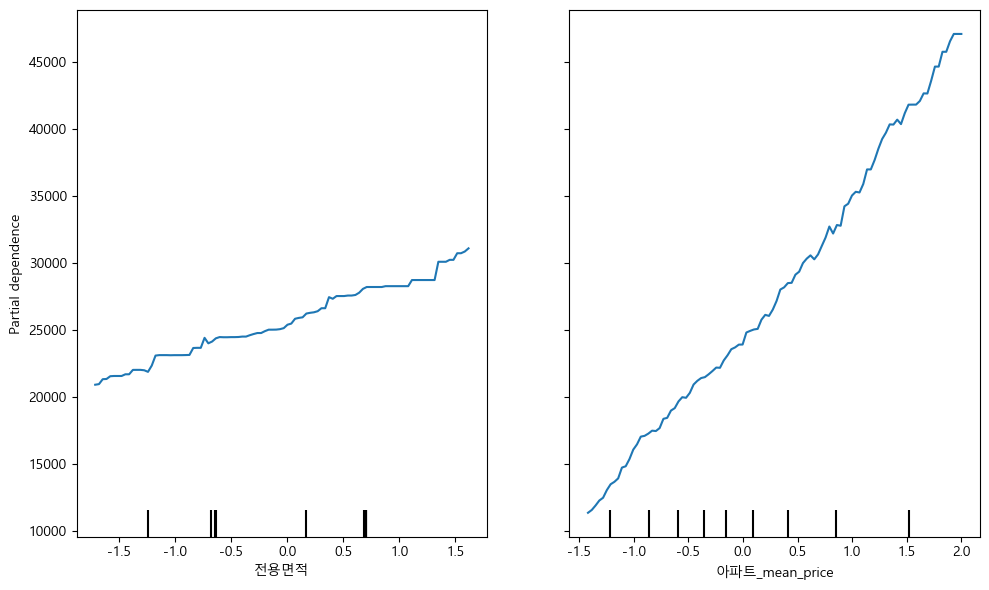

In [13]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 음수 기호 깨짐 방지


# LightGBM 모델은 이미 훈련된 상태
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_scaled, features=[0, 6],  # 전용면적, 아파트 평균 거래가
                                        feature_names=feature_names, ax=ax)
plt.tight_layout()
plt.show()


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


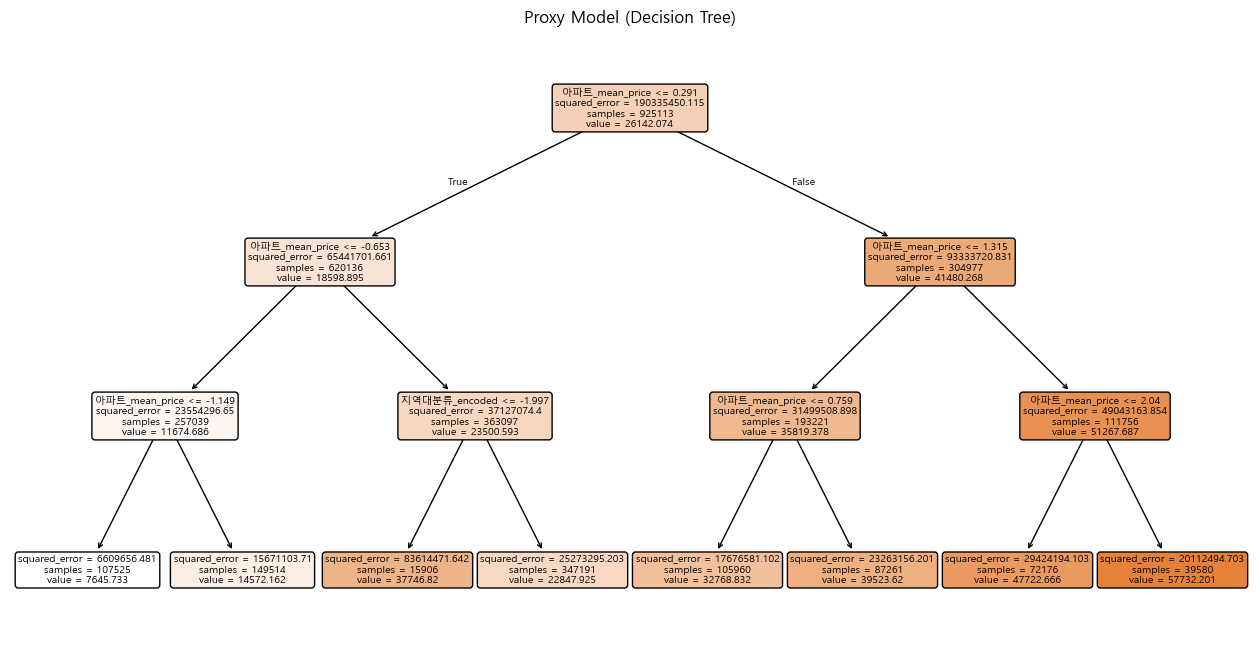

In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

proxy_model = DecisionTreeRegressor(max_depth=3, random_state=42)
proxy_model.fit(X_scaled, model.predict(X_scaled))  # LGBM 예측값을 타겟으로

plt.figure(figsize=(16, 8))
plot_tree(proxy_model, feature_names=feature_names, filled=True, rounded=True)
plt.title("Proxy Model (Decision Tree)")
plt.show()


🧹 제거된 컬럼들 (문제 있는 분포): []

🔍 0번째 샘플 LIME 설명:
Intercept 22106.78069005145
Prediction_local [37972.32286123]
Right: 37114.91085327979


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15588\1579552382.py:48: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


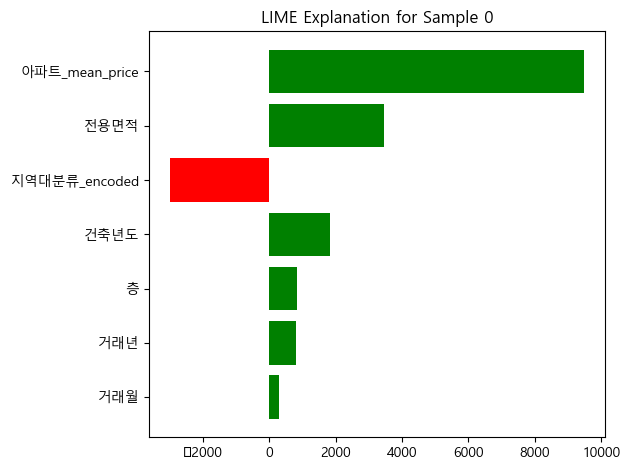


🔍 10번째 샘플 LIME 설명:
Intercept 22111.084382085683
Prediction_local [40261.56572584]
Right: 41711.7333271071


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15588\1579552382.py:48: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


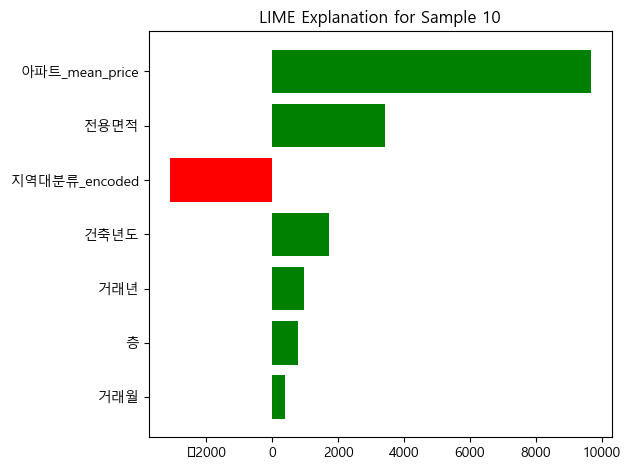


🔍 25번째 샘플 LIME 설명:
Intercept 22299.6402544679
Prediction_local [22911.43261458]
Right: 21833.689815906284


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15588\1579552382.py:48: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


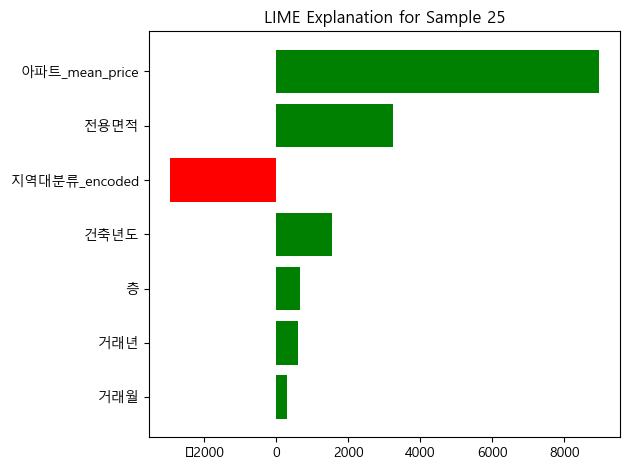


🔍 50번째 샘플 LIME 설명:
Intercept 22177.668745629304
Prediction_local [17268.01474585]
Right: 18435.747124319343


c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15588\1579552382.py:48: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


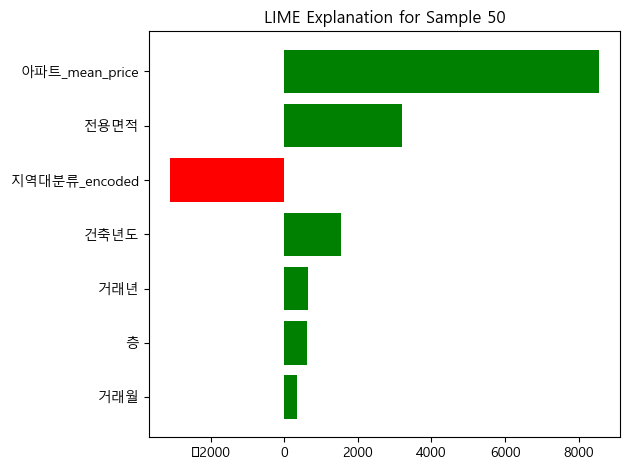

In [11]:
import numpy as np
import pandas as pd
import lime
import lime.lime_tabular
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 거의 같은 값을 가진 변수 제거 함수
def remove_problematic_features(X_df, std_threshold=1e-3, unique_threshold=1):
    stds = X_df.std()
    uniques = X_df.nunique()
    
    low_std_cols = stds[stds < std_threshold].index.tolist()
    low_unique_cols = uniques[uniques <= unique_threshold].index.tolist()
    
    to_remove = list(set(low_std_cols + low_unique_cols))
    print("🧹 제거된 컬럼들 (문제 있는 분포):", to_remove)
    return X_df.drop(columns=to_remove), to_remove

# 2. 적용
X_lime, removed_cols = remove_problematic_features(X)

# 3. 스케일링
scaler_lime = StandardScaler()
X_scaled_lime = scaler_lime.fit_transform(X_lime)

# 4. feature 이름 정리
feature_names_lime = [col for col in feature_names if col not in removed_cols]

# LIME 설명기 재정의 (분포 생성 없이 실수값 그대로 사용)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime.values,
    feature_names=feature_names_lime,
    class_names=['Price'],
    mode='regression',
    discretize_continuous=False,  # ⭐ 분포 생성 안함
    verbose=True
)

# 6. 예측 함수
predict_fn = lambda x: model.predict(scaler_lime.transform(x))

for i in [0, 10, 25, 50]:
    print(f"\n🔍 {i}번째 샘플 LIME 설명:")
    exp = explainer.explain_instance(X_lime.values[i], predict_fn, num_features=7)
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation for Sample {i}")
    plt.tight_layout()
    plt.show()


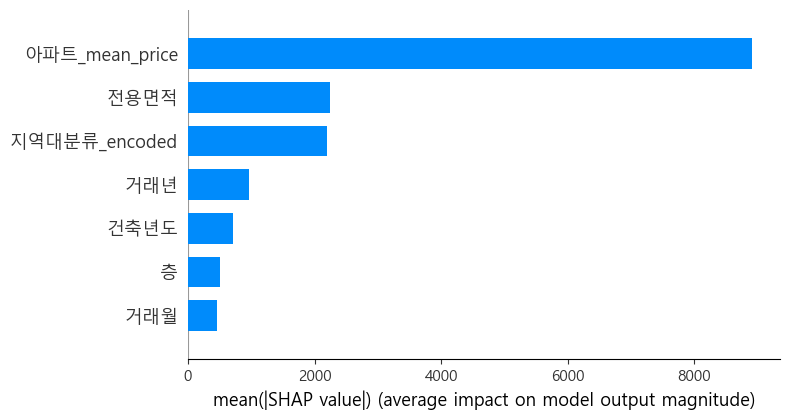

c:\Users\minky\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  pl.tight_layout()
C:\Users\minky\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


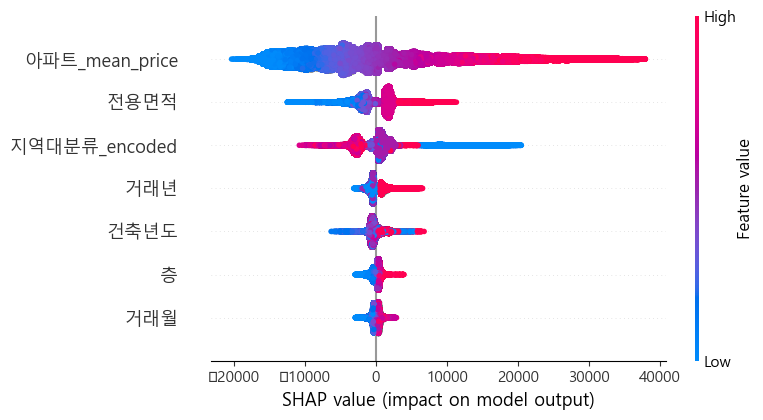

In [12]:
import shap

# TreeExplainer 명시적으로 사용
explainer = shap.TreeExplainer(model)

# SHAP 값 계산 (X_scaled만 넣음)
shap_values = explainer.shap_values(X_scaled)

# 변수명 지정 (그래프용)
feature_names = ['전용면적', '층', '건축년도', '거래년', '거래월', '지역대분류_encoded', '아파트_mean_price']
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

shap.summary_plot(shap_values, X_scaled_df, plot_type="bar")  # bar plot
shap.summary_plot(shap_values, X_scaled_df)  # beeswarm plot